# Amazon Fine Food Review Sentiment Analysis

This notebook builds a beginner-friendly NLP sentiment analysis model using the Amazon Fine Food Reviews dataset. The goal is to classify reviews as **positive** or **negative** using text preprocessing, TF-IDF vectorization, and Multinomial Naive Bayes.

## 1. Import Libraries

We use Pandas for data handling, NLTK for text preprocessing, Scikit-learn for machine learning, and Matplotlib/Seaborn for visualization.

In [1]:
import pickle
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

sns.set_style("whitegrid")

## 2. Load Dataset

The dataset file should be named `Reviews.csv`. In Colab, upload the file to the working directory. In the GitHub project, keep it inside the `data/` folder.

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "Reviews.csv"

if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT.parent / "data" / "Reviews.csv"

if not DATA_PATH.exists():
    DATA_PATH = Path("Reviews.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("Please keep Reviews.csv inside the data folder.")

df = pd.read_csv(DATA_PATH)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

Dataset shape: (568454, 10)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


## 3. Sample the Dataset

The original dataset is large. A sample of 30,000 rows keeps training fast while still giving enough data for a meaningful student project.

In [4]:
SAMPLE_SIZE = 30000

if len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42)

print("Sampled dataset shape:", df.shape)

Sampled dataset shape: (30000, 10)


## 4. Create Sentiment Labels

Amazon scores are converted into sentiment labels:

- Scores 4 and 5 are treated as positive
- Scores 1 and 2 are treated as negative
- Score 3 is removed because it is neutral

In [5]:
def get_sentiment(score):
    if score >= 4:
        return "positive"
    if score <= 2:
        return "negative"
    return "neutral"


df["sentiment"] = df["Score"].apply(get_sentiment)
df = df[df["sentiment"] != "neutral"].copy()

df[["Text", "Score", "sentiment"]].head()

,Text,Score,sentiment
165256,Having tried a couple of other brands of glute...,5,positive
231465,My cat loves these treats. If ever I can't fin...,5,positive
433954,"First there was Frosted Mini-Wheats, in origin...",2,negative
70260,and I want to congratulate the graphic artist ...,5,positive
49866,Please add more Pineapple flavor to your packa...,4,positive


## 5. Visualize Sentiment Distribution

This plot shows whether the dataset is balanced or imbalanced after removing neutral reviews.

/var/folders/ns/wcjhb32s76n73chv3wyv_wdh0000gn/T/ipykernel_14896/44891444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", order=["positive", "negative"], palette="Set2")


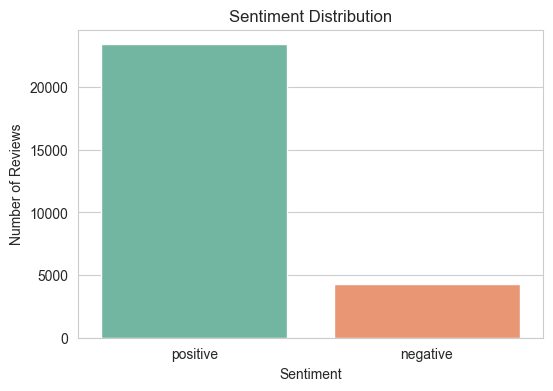

sentiment
positive    23423
negative     4306
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment", order=["positive", "negative"], palette="Set2")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

print(df["sentiment"].value_counts())

## 6. Text Preprocessing

The preprocessing function cleans each review by lowercasing text, removing special characters, removing stopwords, and applying stemming. This converts raw review text into a simpler form suitable for machine learning.

In [7]:
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)

# Keep negation words because they are important for sentiment.
stop_words = stop_words - {"no", "not", "never", "nor"}


def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

In [8]:
df["clean_text"] = df["Text"].apply(preprocess)
df[["Text", "clean_text"]].head()

,Text,clean_text
165256,Having tried a couple of other brands of glute...,have tri coupl brand gluten free sandwich cook...
231465,My cat loves these treats. If ever I can't fin...,cat love treat t hous just pop bolt hide come ...
433954,"First there was Frosted Mini-Wheats, in origin...",frost mini wheat origin size frost mini wheat ...
70260,and I want to congratulate the graphic artist ...,want congratul graphic artist put entir produc...
49866,Please add more Pineapple flavor to your packa...,add pineappl flavor packag lifesav fact sell p...


## 7. Top Frequent Words

The most frequent words help us understand common terms appearing in the cleaned review text.

/var/folders/ns/wcjhb32s76n73chv3wyv_wdh0000gn/T/ipykernel_14896/1692635961.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


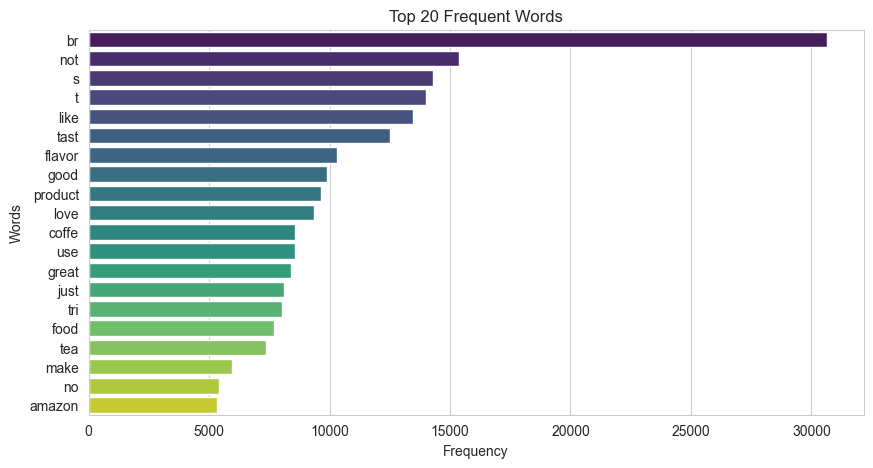

In [9]:
all_words = " ".join(df["clean_text"]).split()
word_counts = Counter(all_words).most_common(20)
words, counts = zip(*word_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

## 8. TF-IDF Vectorization

Machine learning models cannot directly understand text. TF-IDF converts cleaned reviews into numerical features based on word importance.

In [10]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (27729, 5000)


## 9. Train-Test Split

The data is split into training and testing sets. The model learns from the training set and is evaluated on unseen test data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 22183
Testing samples: 5546


## 10. Train Multinomial Naive Bayes Model

Multinomial Naive Bayes is commonly used for text classification because it works well with word-frequency based features such as TF-IDF.

In [12]:
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


## 11. Model Evaluation

We evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix.

In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8673

Classification Report:

              precision    recall  f1-score   support

    negative       0.92      0.16      0.27       861
    positive       0.87      1.00      0.93      4685

    accuracy                           0.87      5546
   macro avg       0.89      0.58      0.60      5546
weighted avg       0.87      0.87      0.83      5546



## 12. Confusion Matrix Heatmap

The confusion matrix shows how many positive and negative reviews were correctly or incorrectly classified.

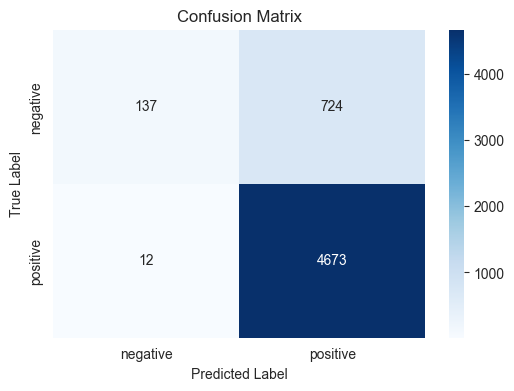

In [14]:
labels = ["negative", "positive"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 13. Save Model and Vectorizer

Pickle is used to save the trained model and TF-IDF vectorizer. These saved files are reused by the Streamlit app.

In [15]:
model_dir = PROJECT_ROOT / "models"
model_dir.mkdir(exist_ok=True)

with open(model_dir / "sentiment_model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

with open(model_dir / "tfidf_vectorizer.pkl", "wb") as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

print("Model and vectorizer saved successfully")

Model and vectorizer saved successfully


## 14. Custom Sentiment Prediction

This function applies the same preprocessing and TF-IDF transformation before predicting sentiment for a custom review.

In [16]:
def predict_sentiment(review):
    cleaned_review = preprocess(review)
    review_vector = vectorizer.transform([cleaned_review])
    prediction = model.predict(review_vector)[0]
    return prediction


positive_review = "This product is absolutely amazing and I loved it"
negative_review = "This was a terrible product and I hated it"

print("Positive example:", predict_sentiment(positive_review))
print("Negative example:", predict_sentiment(negative_review))

Positive example: positive
Negative example: negative


## 15. Conclusion

The project demonstrates a complete traditional NLP workflow using preprocessing, TF-IDF features, Naive Bayes classification, evaluation metrics, visualizations, and model saving. It is simple enough for a second-year student portfolio while still showing practical machine learning project structure.